# 🌊 Underwater Image Enhancement
## Preprocessing + Kombinasi 4 (Attention Transfer) + Kombinasi 5 (Sharpness Specialist)

## 📦 BAGIAN 1 — PREPROCESSING

In [1]:
# CELL 1 — IMPORT LIBRARY
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


2026-05-13 07:15:20.675957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778656521.114265      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778656521.233473      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778656522.242636      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778656522.242677      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778656522.242680      23 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# CELL 2 — LOAD DATASET (via Add Input, tidak perlu download)
DATA_PATH = "/kaggle/input/datasets/colorlabeilat/seathru-dataset"
print("Dataset path:", DATA_PATH)
print("Scenes:", os.listdir(DATA_PATH))


Dataset path: /kaggle/input/datasets/colorlabeilat/seathru-dataset
Scenes: ['D5', 'D2', 'D4', 'D1', 'D3']


In [3]:
# CELL 3 — CONFIG
SCENES     = ["D1", "D2", "D3", "D4", "D5"]
PATCH_SIZE = 256
BATCH_SIZE = 4    # 4 agar tidak OOM di GPU T4
SEED       = 42


In [4]:
# CELL 4 — BUILD IMAGE-DEPTH PAIRS
all_pairs = []

for scene in SCENES:
    base_path = os.path.join(DATA_PATH, scene, scene)
    img_dir   = os.path.join(base_path, "linearPNG")

    if os.path.exists(os.path.join(base_path, "depth")):
        depth_dir = os.path.join(base_path, "depth")
    elif os.path.exists(os.path.join(base_path, "depth_resized")):
        depth_dir = os.path.join(base_path, "depth_resized")
    else:
        print(f"Skipping {scene}: no depth folder")
        continue

    img_files   = sorted(os.listdir(img_dir))
    depth_files = sorted(os.listdir(depth_dir))
    img_dict    = {os.path.splitext(f)[0]: f for f in img_files}
    depth_dict  = {os.path.splitext(f)[0].replace("depth", ""): f for f in depth_files}
    common_keys = sorted(set(img_dict.keys()) & set(depth_dict.keys()))
    print(f"{scene}: {len(common_keys)} matched pairs")

    for key in common_keys:
        all_pairs.append((
            os.path.join(img_dir,   img_dict[key]),
            os.path.join(depth_dir, depth_dict[key])
        ))

print("\nTotal image-depth pairs:", len(all_pairs))


D1: 622 matched pairs
D2: 319 matched pairs
D3: 68 matched pairs
D4: 153 matched pairs
D5: 43 matched pairs

Total image-depth pairs: 1205


In [5]:
# CELL 5 — COMPUTE GLOBAL DEPTH MAX
depth_max_values = []
for _, depth_path in all_pairs:
    depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED).astype(np.float32)
    depth_max_values.append(np.max(depth))

GLOBAL_DEPTH_MAX = np.max(depth_max_values)
print("GLOBAL_DEPTH_MAX:", GLOBAL_DEPTH_MAX)
np.save("global_depth_max.npy", GLOBAL_DEPTH_MAX)


GLOBAL_DEPTH_MAX: 26.075403


In [6]:
# CELL 6 — SPLIT BEFORE PATCHING

train_pairs, test_pairs = train_test_split(all_pairs, test_size=0.15, random_state=SEED)
train_pairs, val_pairs  = train_test_split(train_pairs, test_size=0.15, random_state=SEED)

print(f"Train images : {len(train_pairs)}")
print(f"Val images   : {len(val_pairs)}")
print(f"Test images  : {len(test_pairs)}")

np.save("train_pairs.npy", train_pairs)
np.save("val_pairs.npy",   val_pairs)
np.save("test_pairs.npy",  test_pairs)


Train images : 870
Val images   : 154
Test images  : 181


In [7]:
# CELL 7 — SAVE CONFIG
config = {
    "PATCH_SIZE"      : PATCH_SIZE,
    "BATCH_SIZE"      : BATCH_SIZE,
    "GLOBAL_DEPTH_MAX": float(GLOBAL_DEPTH_MAX),
    "SEED"            : SEED
}
np.save("preprocessing_config.npy", config)
print("Config saved!")


Config saved!


In [8]:
# CELL 8 — LOADER RGB + DEPTH + MASK
def load_image_depth(img_file, depth_file):
    img = cv2.imread(img_file, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    img = (img / 65535.0 if img.max() > 255 else img / 255.0)
    img = img * 2.0 - 1.0

    depth      = cv2.imread(depth_file, cv2.IMREAD_UNCHANGED).astype(np.float32)
    valid_mask = np.isfinite(depth).astype(np.float32)
    valid_mask[depth <= 0] = 0
    hole_mask  = (depth <= 0).astype(np.uint8)
    if hole_mask.sum() > 0:
        depth = cv2.inpaint(depth, hole_mask, 3, cv2.INPAINT_NS)
    depth = np.clip(depth / GLOBAL_DEPTH_MAX, 0, 1)
    return img, depth, valid_mask

print("Loader siap!")


Loader siap!


In [9]:
# CELL 9 — PATCH GENERATOR
def patch_generator(pairs):
    for img_path, depth_path in pairs:
        result = load_image_depth(img_path, depth_path)
        if result is None:
            continue
        img, depth, mask = result
        h, w = img.shape[:2]
        for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
            for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
                ip = img  [y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                dp = depth[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                mp = mask [y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                if np.mean(mp) < 0.05:
                    continue
                yield ip, dp, mp

print("Patch generator siap!")


Patch generator siap!


In [10]:
# Batasi steps biar training bisa selesai
TRAIN_STEPS = 500   # dari 11041 -> 500
VAL_STEPS   = 100   # dari 1944  -> 100
EPOCHS4     = 10    # dari 50    -> 10
EPOCHS5     = 10    # dari 50    -> 10

print(f"Train steps : {TRAIN_STEPS}")
print(f"Val steps   : {VAL_STEPS}")
print(f"Epochs C4   : {EPOCHS4}")
print(f"Epochs C5   : {EPOCHS5}")

Train steps : 500
Val steps   : 100
Epochs C4   : 10
Epochs C5   : 10


In [11]:
# CELL 11 — TF.DATA PIPELINE
output_signature = (
    tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE),    dtype=tf.float32),
    tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE),    dtype=tf.float32),
)

train_ds = tf.data.Dataset.from_generator(lambda: patch_generator(train_pairs), output_signature=output_signature)
val_ds   = tf.data.Dataset.from_generator(lambda: patch_generator(val_pairs),   output_signature=output_signature)
test_ds  = tf.data.Dataset.from_generator(lambda: patch_generator(test_pairs),  output_signature=output_signature)


I0000 00:00:1778657003.342134      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778657003.348875      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
# CELL 12 — AUGMENTATION
@tf.function
def augment(rgb, depth, mask):
    combined = tf.concat([rgb, depth[..., None], mask[..., None]], axis=-1)
    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_left_right(combined)
    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_up_down(combined)
    combined = tf.image.rot90(combined, tf.random.uniform([], 0, 4, dtype=tf.int32))
    return combined[..., :3], combined[..., 3], combined[..., 4]


In [13]:
# CELL 13 — FINAL DATASET PIPELINE
# train_ds pakai .repeat() -> infinite, WAJIB set TRAIN_STEPS saat training!
train_ds = (
    train_ds
    .shuffle(200)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

print("TF.DATA pipeline ready!")
print(f"BATCH_SIZE={BATCH_SIZE} | TRAIN_STEPS={TRAIN_STEPS} | VAL_STEPS={VAL_STEPS}")


TF.DATA pipeline ready!
BATCH_SIZE=4 | TRAIN_STEPS=500 | VAL_STEPS=100


In [14]:
# CELL 14 — CHECK SAMPLE BATCH
for rgb, depth, mask in train_ds.take(1):
    print("RGB batch  :", rgb.shape)
    print("Depth batch:", depth.shape)
    print("Mask batch :", mask.shape)
    print("RGB range  :", float(rgb.numpy().min()), "~", float(rgb.numpy().max()))


RGB batch  : (4, 256, 256, 3)
Depth batch: (4, 256, 256)
Mask batch : (4, 256, 256)
RGB range  : -0.9932249784469604 ~ -0.3781643509864807


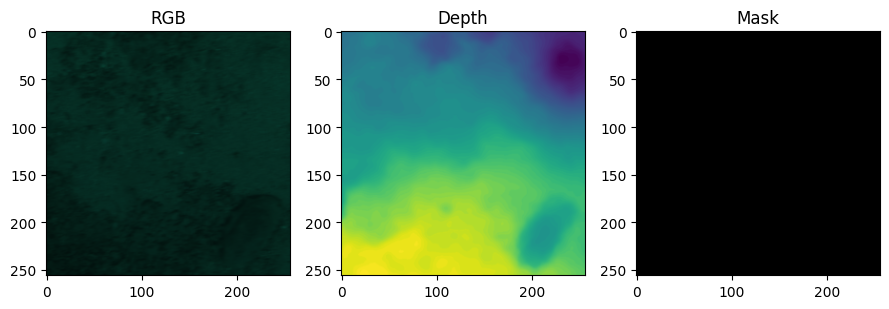

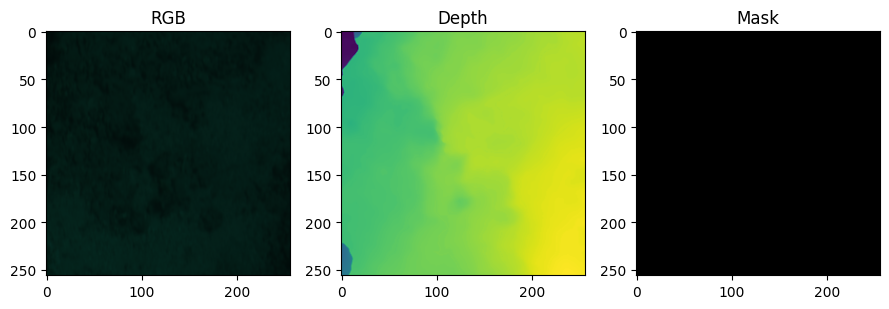

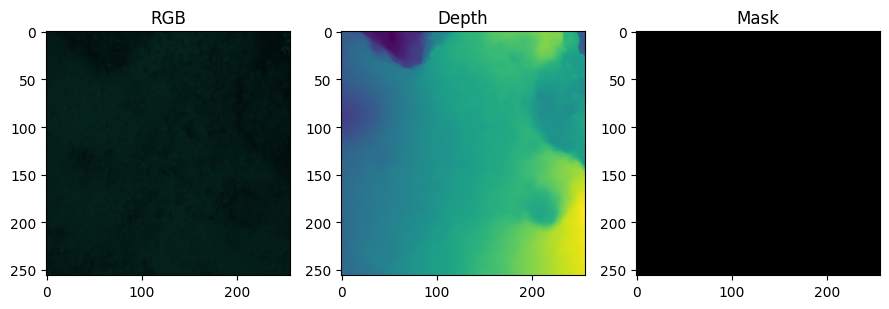

In [15]:
# CELL 15 — VISUALIZATION
for rgb_batch, depth_batch, mask_batch in train_ds.take(1):
    for i in range(min(3, BATCH_SIZE)):
        plt.figure(figsize=(9, 3))
        plt.subplot(1,3,1); plt.imshow((rgb_batch[i].numpy()+1)/2); plt.title("RGB")
        plt.subplot(1,3,2); plt.imshow(depth_batch[i].numpy(), cmap="viridis"); plt.title("Depth")
        plt.subplot(1,3,3); plt.imshow(mask_batch[i].numpy(), cmap="gray"); plt.title("Mask")
        plt.tight_layout(); plt.show()


---
## 🔧 BAGIAN 2 — SHARED UTILITIES

In [16]:
# CELL 16 — HELPER FUNCTIONS
def make_4ch(rgb, depth):
    """Gabungkan RGB + Depth jadi 4 channel input model"""
    return tf.concat([rgb, depth[..., tf.newaxis]], axis=-1)


def generate_pseudo_gt(rgb, depth, mask):
    """
    Pseudo GT via inversi fisika Sea-thru.
    Rumus: I = J*e^(-beta*z) + B*(1-e^(-beta*z))
    Inverse: J = (I - B*(1-T)) / T  dimana T = e^(-beta*z)
    """
    rgb_01   = (rgb + 1.0) / 2.0
    depth_4d = depth[..., tf.newaxis]
    mask_4d  = mask[..., tf.newaxis]
    beta      = tf.constant([[[0.8, 0.4, 0.1]]], dtype=tf.float32)
    T         = tf.exp(-beta * depth_4d)
    B         = 0.5
    corrected = tf.clip_by_value((rgb_01 - B*(1.0-T)) / tf.maximum(T, 0.1), 0.0, 1.0)
    gt_01     = corrected * mask_4d + rgb_01 * (1.0 - mask_4d)
    return gt_01 * 2.0 - 1.0


def rec_loss(y_true, y_pred, mask=None):
    diff = tf.abs(y_true - y_pred)
    if mask is not None:
        m = mask[..., tf.newaxis]
        return tf.reduce_sum(diff * m) / (tf.reduce_sum(m) * 3 + 1e-8)
    return tf.reduce_mean(diff)


def dist_loss(t_out, s_out):
    return tf.reduce_mean(tf.square(t_out - s_out))


def perc_loss(y_true, y_pred, perc_model):
    to_vgg = lambda x: (x + 1.0) * 127.5
    return tf.reduce_mean(tf.abs(perc_model(to_vgg(y_true)) - perc_model(to_vgg(y_pred))))

print("Helper functions siap!")


Helper functions siap!


In [17]:
# CELL 17 — BUILDING BLOCKS
# Semua pakai Keras Layer class -> tidak error KerasTensor

class InstanceNorm(layers.Layer):
    def build(self, input_shape):
        c = input_shape[-1]
        self.gamma = self.add_weight('gamma', (c,), initializer='ones')
        self.beta  = self.add_weight('beta',  (c,), initializer='zeros')
    def call(self, x):
        mu, var = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return self.gamma * (x - mu) / tf.sqrt(var + 1e-5) + self.beta


def conv_block(x, f):
    for _ in range(2):
        x = layers.Conv2D(f, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    return x


def dw_sep_conv(x, filters, strides=1):
    x = layers.DepthwiseConv2D(3, strides=strides, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(6.0)(x)
    x = layers.Conv2D(filters, 1)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(6.0)(x)
    return x


class TransformerBlock(layers.Layer):
    """Transformer Block sebagai Keras Layer (wajib, tidak bisa pakai tf.reshape di luar Layer)"""
    def __init__(self, embed_dim, num_heads, mlp_dim, num_layers=4, **kwargs):
        super().__init__(**kwargs)
        self.num_layers = num_layers
        self.attns = [layers.MultiHeadAttention(num_heads=num_heads,
                       key_dim=embed_dim//num_heads) for _ in range(num_layers)]
        self.ff1s  = [layers.Dense(mlp_dim, activation='gelu') for _ in range(num_layers)]
        self.ff2s  = [layers.Dense(embed_dim) for _ in range(num_layers)]
        self.norms = [layers.LayerNormalization() for _ in range(num_layers * 2)]

    def call(self, x):
        B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]; C = x.shape[3]
        seq = tf.reshape(x, [B, H*W, C])
        for i in range(self.num_layers):
            attn = self.attns[i](seq, seq)
            seq  = self.norms[i*2](seq + attn)
            ff   = self.ff2s[i](self.ff1s[i](seq))
            seq  = self.norms[i*2+1](seq + ff)
        return tf.reshape(seq, [B, H, W, C])


class MobileViTBlock(layers.Layer):
    """
    MobileViT Block dengan LOCAL attention (patch 8x8).
    Fix OOM: attention hanya dalam patch kecil, bukan seluruh gambar.
    Token size: 8x8=64 (bukan 64x64=4096 yang OOM)
    """
    def __init__(self, embed_dim, num_heads=4, num_layers=2, patch_h=8, patch_w=8, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim  = embed_dim
        self.num_heads  = num_heads
        self.num_layers = num_layers
        self.patch_h    = patch_h
        self.patch_w    = patch_w

    def build(self, input_shape):
        C = input_shape[-1]
        self.conv_in  = layers.Conv2D(self.embed_dim, 3, padding='same')
        self.attns    = [layers.MultiHeadAttention(num_heads=self.num_heads,
                          key_dim=self.embed_dim//self.num_heads) for _ in range(self.num_layers)]
        self.ff1s     = [layers.Dense(self.embed_dim*2, activation='gelu') for _ in range(self.num_layers)]
        self.ff2s     = [layers.Dense(self.embed_dim) for _ in range(self.num_layers)]
        self.norms    = [layers.LayerNormalization() for _ in range(self.num_layers*2)]
        self.conv_out = layers.Conv2D(C, 1)
        self.cat      = layers.Concatenate()

    def call(self, x):
        shortcut = x
        B  = tf.shape(x)[0]
        H  = tf.shape(x)[1]
        W  = tf.shape(x)[2]
        ph = self.patch_h
        pw = self.patch_w
        nH = H // ph
        nW = W // pw
        out = self.conv_in(x)
        # Local attention: reshape jadi patch-patch kecil
        out = tf.reshape(out, [B * nH * nW, ph * pw, self.embed_dim])
        for i in range(self.num_layers):
            attn = self.attns[i](out, out)
            out  = self.norms[i*2](out + attn)
            ff   = self.ff2s[i](self.ff1s[i](out))
            out  = self.norms[i*2+1](out + ff)
        # Unfold balik ke spatial
        out = tf.reshape(out, [B, H, W, self.embed_dim])
        out = self.conv_out(out)
        return self.cat([shortcut, out])

print("Building blocks siap!")


Building blocks siap!


---
## 🎨 BAGIAN 3 — KOMBINASI 4: Attention Transfer
**Teacher:** U-Transformer | **Student:** MobileViT | **Baseline:** FUnIE-GAN

In [18]:
# CELL 18 — KOMBINASI 4: BUILD MODELS
def build_u_transformer(input_shape=(PATCH_SIZE, PATCH_SIZE, 4)):
    """Teacher: U-Transformer (input 4ch RGB+Depth)"""
    inp = keras.Input(shape=input_shape)
    e1  = conv_block(inp, 64)
    e2  = conv_block(layers.MaxPooling2D(2)(e1), 128)
    e3  = conv_block(layers.MaxPooling2D(2)(e2), 256)
    e4  = conv_block(layers.MaxPooling2D(2)(e3), 512)
    b   = layers.Conv2D(512, 1)(layers.MaxPooling2D(2)(e4))
    b   = TransformerBlock(embed_dim=512, num_heads=8, mlp_dim=1024, num_layers=4)(b)
    d4  = conv_block(layers.Concatenate()([layers.UpSampling2D(2)(b),  e4]), 512)
    d3  = conv_block(layers.Concatenate()([layers.UpSampling2D(2)(d4), e3]), 256)
    d2  = conv_block(layers.Concatenate()([layers.UpSampling2D(2)(d3), e2]), 128)
    d1  = conv_block(layers.Concatenate()([layers.UpSampling2D(2)(d2), e1]), 64)
    out = layers.Conv2D(3, 1, activation='tanh')(d1)
    return keras.Model(inp, out, name="U_Transformer_Teacher")


def build_mobilevit_student(input_shape=(PATCH_SIZE, PATCH_SIZE, 4)):
    """Student: MobileViT (input 4ch RGB+Depth)"""
    inp   = keras.Input(shape=input_shape)
    x     = layers.Conv2D(16, 3, padding='same')(inp)
    x     = layers.BatchNormalization()(x)
    x     = layers.ReLU()(x)
    x     = dw_sep_conv(x, 32);        skip1 = x
    x     = dw_sep_conv(x, 64, strides=2); skip2 = x
    x     = dw_sep_conv(x, 96, strides=2)
    # MobileViTBlock dengan local attention patch 8x8 -> tidak OOM
    x     = layers.Conv2D(96, 1)(MobileViTBlock(embed_dim=96,  num_heads=4, num_layers=2, patch_h=8, patch_w=8)(x))
    x     = dw_sep_conv(x, 128, strides=2)
    x     = layers.Conv2D(128, 1)(MobileViTBlock(embed_dim=128, num_heads=4, num_layers=3, patch_h=4, patch_w=4)(x))
    x     = dw_sep_conv(layers.UpSampling2D(2)(x), 96)
    x     = dw_sep_conv(layers.Concatenate()([layers.UpSampling2D(2)(x), skip2]), 64)
    x     = dw_sep_conv(layers.Concatenate()([layers.UpSampling2D(2)(x), skip1]), 32)
    out   = layers.Conv2D(3, 1, activation='tanh')(x)
    return keras.Model(inp, out, name="MobileViT_Student")


teacher4 = build_u_transformer()
student4  = build_mobilevit_student()
teacher4.trainable = False  # WAJIB FROZEN!

print(f"[Combo4] Teacher : {teacher4.count_params():,} params  [FROZEN]")
print(f"[Combo4] Student : {student4.count_params():,} params")


[Combo4] Teacher : 23,551,683 params  [FROZEN]
[Combo4] Student : 913,075 params


In [19]:
# CELL 19 — KOMBINASI 4: LOSS & OPTIMIZER
_vgg4 = keras.applications.VGG19(include_top=False, weights='imagenet')
_vgg4.trainable = False
_perc4 = keras.Model(_vgg4.input, _vgg4.get_layer("block3_conv3").output)

LR4          = 2e-4
LAMBDA_REC4  = 1.0
LAMBDA_DIST4 = 0.5
LAMBDA_PER4  = 0.1
EPOCHS4      = 50

opt4 = keras.optimizers.Adam(LR4, beta_1=0.5)
print("Loss & optimizer Combo 4 siap!")


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loss & optimizer Combo 4 siap!


In [20]:
# CELL 20 — KOMBINASI 4: TRAIN STEP
@tf.function
def train_step_4(rgb, depth, mask):
    inp_4ch   = make_4ch(rgb, depth)
    pseudo_gt = generate_pseudo_gt(rgb, depth, mask)
    t_out     = teacher4(inp_4ch, training=False)  # Teacher FROZEN

    with tf.GradientTape() as tape:
        s_out  = student4(inp_4ch, training=True)
        l_rec  = rec_loss(pseudo_gt, s_out, mask)
        l_dist = dist_loss(t_out, s_out)
        l_per  = perc_loss(pseudo_gt, s_out, _perc4)
        total  = LAMBDA_REC4*l_rec + LAMBDA_DIST4*l_dist + LAMBDA_PER4*l_per

    grads = tape.gradient(total, student4.trainable_variables)
    opt4.apply_gradients(zip(grads, student4.trainable_variables))
    return {"total": total, "rec": l_rec, "dist": l_dist, "per": l_per}

print("Train step Combo 4 siap!")


Train step Combo 4 siap!


In [21]:
# Fix save weights — ganti ekstensi ke .weights.h5
# Jalanin ini sebelum training loop!

# Untuk Combo 4
def save_combo4():
    student4.save_weights("/kaggle/working/best_student_combo4.weights.h5")

# Untuk Combo 5    
def save_combo5():
    generator5.save_weights("/kaggle/working/best_generator_combo5.weights.h5")

In [22]:
# CELL 21 — KOMBINASI 4: TRAINING LOOP
best_val4 = float('inf')

for epoch in range(EPOCHS4):
    # Training
    t_losses = []
    for step, (rgb, depth, mask) in enumerate(train_ds):
        if step >= TRAIN_STEPS:
            break
        losses = train_step_4(rgb, depth, mask)
        t_losses.append(losses["total"].numpy())

    # Validation
    v_losses = []
    for step, (rgb, depth, mask) in enumerate(val_ds):
        if step >= VAL_STEPS:
            break
        inp   = make_4ch(rgb, depth)
        gt    = generate_pseudo_gt(rgb, depth, mask)
        s_out = student4(inp, training=False)
        t_out = teacher4(inp, training=False)
        v_losses.append((LAMBDA_REC4  * rec_loss(gt, s_out, mask) +
                         LAMBDA_DIST4 * dist_loss(t_out, s_out)).numpy())

    avg_t, avg_v = np.mean(t_losses), np.mean(v_losses)
    print(f"Epoch {epoch+1}/{EPOCHS4} | Train: {avg_t:.4f} | Val: {avg_v:.4f}")

    if avg_v < best_val4:
        best_val4 = avg_v
        student4.save_weights("/kaggle/working/best_student_combo4.weights.h5")
        print("  => Tersimpan!")

print("\n[Combo4] Training selesai!")

I0000 00:00:1778657042.822331      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch 1/50 | Train: 17.3105 | Val: 0.4940
  => Tersimpan!
Epoch 2/50 | Train: 3.6173 | Val: 0.4884
  => Tersimpan!
Epoch 3/50 | Train: 2.8186 | Val: 0.4804
  => Tersimpan!
Epoch 4/50 | Train: 2.5099 | Val: 0.4780
  => Tersimpan!
Epoch 5/50 | Train: 2.2917 | Val: 0.4752
  => Tersimpan!
Epoch 6/50 | Train: 2.0850 | Val: 0.4722
  => Tersimpan!
Epoch 7/50 | Train: 1.9526 | Val: 0.4703
  => Tersimpan!
Epoch 8/50 | Train: 1.8339 | Val: 0.4699
  => Tersimpan!
Epoch 9/50 | Train: 1.7731 | Val: 0.4726
Epoch 10/50 | Train: 1.7021 | Val: 0.4679
  => Tersimpan!
Epoch 11/50 | Train: 1.6526 | Val: 0.4709
Epoch 12/50 | Train: 1.5991 | Val: 0.4814
Epoch 13/50 | Train: 1.5618 | Val: 0.4676
  => Tersimpan!
Epoch 14/50 | Train: 1.5638 | Val: 0.4754
Epoch 15/50 | Train: 1.5138 | Val: 0.4700
Epoch 16/50 | Train: 1.4820 | Val: 0.4708
Epoch 17/50 | Train: 1.4699 | Val: 0.4704
Epoch 18/50 | Train: 1.4390 | Val: 0.4703
Epoch 19/50 | Train: 1.4166 | Val: 0.4682
Epoch 20/50 | Train: 1.4058 | Val: 0.4765
Epoch 21

In [23]:
# CELL 22 — KOMBINASI 4: EVALUASI
from tensorflow.image import psnr as tf_psnr, ssim as tf_ssim

student4.load_weights("/kaggle/working/best_student_combo4.weights.h5")

psnr4, ssim4 = [], []
for rgb, depth, mask in test_ds:
    pred = student4(make_4ch(rgb, depth), training=False)
    gt   = generate_pseudo_gt(rgb, depth, mask)
    p_dn = (pred + 1.0) / 2.0
    g_dn = (gt   + 1.0) / 2.0
    psnr4.extend(tf_psnr(g_dn, p_dn, max_val=1.0).numpy().flatten())
    ssim4.extend(tf_ssim(g_dn, p_dn, max_val=1.0).numpy().flatten())

print("\n========== HASIL EVALUASI KOMBINASI 4 ==========")
print(f"PSNR rata-rata : {np.mean(psnr4):.2f} dB")
print(f"SSIM rata-rata : {np.mean(ssim4):.4f}")



========== HASIL EVALUASI KOMBINASI 4 ==========
PSNR rata-rata : 40.94 dB
SSIM rata-rata : 0.9261


---
## 🔍 BAGIAN 4 — KOMBINASI 5: Sharpness Specialist
**Teacher:** DeepSESR | **Student:** Tiny-GAN | **Baseline:** UGAN

In [24]:
# CELL 23 — KOMBINASI 5: BUILD MODELS
class InstanceNorm(layers.Layer):
    def build(self, input_shape):
        c = input_shape[-1]
        self.gamma = self.add_weight(name='gamma', shape=(c,), initializer='ones')
        self.beta  = self.add_weight(name='beta',  shape=(c,), initializer='zeros')
    def call(self, x):
        mu, var = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return self.gamma * (x - mu) / tf.sqrt(var + 1e-5) + self.beta
        
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    return layers.Add()([shortcut, x])


def dense_block(x, filters, num_layers=4):
    feats = [x]
    for _ in range(num_layers):
        inp = layers.Concatenate()(feats) if len(feats) > 1 else feats[0]
        f   = layers.BatchNormalization()(
              layers.Conv2D(filters, 3, padding='same', activation='relu')(inp))
        feats.append(f)
    return feats[-1]


def build_deep_sesr(input_shape=(PATCH_SIZE, PATCH_SIZE, 4), num_res=16):
    """Teacher: DeepSESR (input 4ch RGB+Depth)"""
    inp  = keras.Input(shape=input_shape)
    x    = layers.PReLU(shared_axes=[1, 2])(layers.Conv2D(64, 9, padding='same')(inp))
    init = x
    x    = dense_block(x, 64)
    x    = dense_block(x, 64)
    for _ in range(num_res):
        x = residual_block(x, 64)
    x   = layers.Add()([layers.BatchNormalization()(layers.Conv2D(64, 3, padding='same')(x)), init])
    x   = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x   = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    out = layers.Conv2D(3,  1, activation='tanh')(x)
    return keras.Model(inp, out, name="DeepSESR_Teacher")


def tiny_gen_block(x, filters):
    s = x
    x = InstanceNorm()(layers.Conv2D(filters, 3, padding='same')(x))
    x = layers.ReLU()(x)
    x = InstanceNorm()(layers.Conv2D(filters, 3, padding='same')(x))
    return layers.Add()([x, s]) if s.shape[-1] == filters else x


def build_tiny_gan_generator(input_shape=(PATCH_SIZE, PATCH_SIZE, 4)):
    """Student: Tiny-GAN Generator (input 4ch RGB+Depth)"""
    inp = keras.Input(shape=input_shape)
    e1  = layers.LeakyReLU(0.2)(layers.Conv2D(32, 4, strides=2, padding='same')(inp))
    e2  = layers.LeakyReLU(0.2)(InstanceNorm()(layers.Conv2D(64,  4, strides=2, padding='same')(e1)))
    e3  = layers.LeakyReLU(0.2)(InstanceNorm()(layers.Conv2D(128, 4, strides=2, padding='same')(e2)))
    b   = e3
    for _ in range(4):
        b = tiny_gen_block(b, 128)
    d3  = layers.ReLU()(InstanceNorm()(layers.Conv2DTranspose(64, 4, strides=2, padding='same')(b)))
    d3  = layers.Conv2D(64, 1)(layers.Concatenate()([d3, e2]))
    d2  = layers.ReLU()(InstanceNorm()(layers.Conv2DTranspose(32, 4, strides=2, padding='same')(d3)))
    d2  = layers.Conv2D(32, 1)(layers.Concatenate()([d2, e1]))
    d1  = layers.ReLU()(layers.Conv2DTranspose(16, 4, strides=2, padding='same')(d2))
    out = layers.Conv2D(3, 7, padding='same', activation='tanh')(d1)
    return keras.Model(inp, out, name="TinyGAN_Generator")


def build_patch_discriminator(input_shape=(PATCH_SIZE, PATCH_SIZE, 3)):
    """PatchGAN Discriminator (input 3ch RGB output saja)"""
    def disc_block(x, f, stride=2, norm=True):
        x = layers.Conv2D(f, 4, strides=stride, padding='same')(x)
        if norm: x = InstanceNorm()(x)
        return layers.LeakyReLU(0.2)(x)
    inp = keras.Input(shape=input_shape)
    x   = disc_block(inp, 64,  norm=False)
    x   = disc_block(x,   128)
    x   = disc_block(x,   256)
    x   = disc_block(x,   512, stride=1)
    out = layers.Conv2D(1, 4, padding='same')(x)
    return keras.Model(inp, out, name="PatchGAN_Discriminator")


teacher5       = build_deep_sesr()
generator5     = build_tiny_gan_generator()
discriminator5 = build_patch_discriminator()
teacher5.trainable = False  # WAJIB FROZEN!

print(f"[Combo5] Teacher   : {teacher5.count_params():,} params  [FROZEN]")
print(f"[Combo5] Generator : {generator5.count_params():,} params")
print(f"[Combo5] Disc      : {discriminator5.count_params():,} params")


[Combo5] Teacher   : 2,044,291 params  [FROZEN]
[Combo5] Generator : 1,534,243 params
[Combo5] Disc      : 2,766,529 params


In [25]:
# CELL 24 — KOMBINASI 5: LOSS & OPTIMIZER
_vgg5 = keras.applications.VGG19(include_top=False, weights='imagenet')
_vgg5.trainable = False
_perc5 = keras.Model(_vgg5.input, _vgg5.get_layer("block3_conv3").output)
_bce   = keras.losses.BinaryCrossentropy(from_logits=True)

LR_G5        = 1e-4
LR_D5        = 4e-4
LAMBDA_REC5  = 10.0
LAMBDA_DIST5 = 5.0
LAMBDA_ADV5  = 1.0
LAMBDA_EDGE5 = 2.0
EPOCHS5      = 50

opt_G5 = keras.optimizers.Adam(LR_G5, beta_1=0.5)
opt_D5 = keras.optimizers.Adam(LR_D5, beta_1=0.5)


def edge_loss(y_true, y_pred):
    """Sobel Edge Loss — kunci ketajaman objek Combo 5"""
    gt_gray   = tf.image.rgb_to_grayscale(y_true)
    pred_gray = tf.image.rgb_to_grayscale(y_pred)
    e_true    = tf.image.sobel_edges(gt_gray)
    e_pred    = tf.image.sobel_edges(pred_gray)
    mag_true  = tf.sqrt(tf.reduce_sum(tf.square(e_true), axis=-1) + 1e-8)
    mag_pred  = tf.sqrt(tf.reduce_sum(tf.square(e_pred), axis=-1) + 1e-8)
    return tf.reduce_mean(tf.abs(mag_true - mag_pred))

print("Loss & optimizer Combo 5 siap!")


Loss & optimizer Combo 5 siap!


In [26]:
# CELL 25 — KOMBINASI 5: TRAIN STEP (GAN + KD)
@tf.function
def train_step_5(rgb, depth, mask):
    inp_4ch   = make_4ch(rgb, depth)
    pseudo_gt = generate_pseudo_gt(rgb, depth, mask)
    t_out     = teacher5(inp_4ch, training=False)  # Teacher FROZEN

    # Update Discriminator dulu
    with tf.GradientTape() as d_tape:
        fake_rgb  = generator5(inp_4ch,   training=True)
        real_pred = discriminator5(pseudo_gt, training=True)
        fake_pred = discriminator5(fake_rgb,  training=True)
        d_loss    = (_bce(tf.ones_like(real_pred),  real_pred) +
                     _bce(tf.zeros_like(fake_pred), fake_pred)) * 0.5

    d_grads = d_tape.gradient(d_loss, discriminator5.trainable_variables)
    opt_D5.apply_gradients(zip(d_grads, discriminator5.trainable_variables))

    # Update Generator (Student)
    with tf.GradientTape() as g_tape:
        fake_rgb  = generator5(inp_4ch, training=True)
        fake_pred = discriminator5(fake_rgb, training=False)
        g_adv     = _bce(tf.ones_like(fake_pred), fake_pred)
        g_rec     = rec_loss(pseudo_gt, fake_rgb, mask)
        g_dist    = dist_loss(t_out, fake_rgb)
        g_edge    = edge_loss(pseudo_gt, fake_rgb)
        g_per     = perc_loss(pseudo_gt, fake_rgb, _perc5)
        g_loss    = (LAMBDA_ADV5  * g_adv  +
                     LAMBDA_REC5  * g_rec  +
                     LAMBDA_DIST5 * g_dist +
                     LAMBDA_EDGE5 * g_edge +
                     0.1          * g_per)

    g_grads = g_tape.gradient(g_loss, generator5.trainable_variables)
    opt_G5.apply_gradients(zip(g_grads, generator5.trainable_variables))
    return {"g_loss": g_loss, "d_loss": d_loss, "rec": g_rec, "dist": g_dist, "edge": g_edge}

print("Train step Combo 5 siap!")


Train step Combo 5 siap!


In [27]:
# CELL 26 — KOMBINASI 5: TRAINING LOOP
# train_ds pakai .repeat() -> loop manual pakai TRAIN_STEPS
best_val5 = float('inf')

for epoch in range(EPOCHS5):
    print(f"\n{'='*55}")
    print(f"[Combo5] Epoch {epoch+1}/{EPOCHS5}")

    # Training
    g_list, d_list = [], []
    for step, (rgb, depth, mask) in enumerate(train_ds):
        if step >= TRAIN_STEPS:
            break
        losses = train_step_5(rgb, depth, mask)
        g_list.append(losses["g_loss"].numpy())
        d_list.append(losses["d_loss"].numpy())
        
        # NOTE: Bagian print(f" [{step}/{TRAIN_STEPS}]...") dihapus biar nggak spam

    # Validation
    v_list = []
    for step, (rgb, depth, mask) in enumerate(val_ds):
        if step >= VAL_STEPS:
            break
        inp      = make_4ch(rgb, depth)
        gt       = generate_pseudo_gt(rgb, depth, mask)
        fake_rgb = generator5(inp, training=False)
        t_out    = teacher5(inp,  training=False)
        v_loss   = (LAMBDA_REC5  * rec_loss(gt, fake_rgb, mask) +
                    LAMBDA_DIST5 * dist_loss(t_out, fake_rgb) +
                    LAMBDA_EDGE5 * edge_loss(gt, fake_rgb))
        v_list.append(v_loss.numpy())

    # Cuma print hasil rata-rata di akhir epoch
    print(f"  => G: {np.mean(g_list):.4f} | D: {np.mean(d_list):.4f} | Val: {np.mean(v_list):.4f}")

    if np.mean(v_list) < best_val5:
        best_val5 = np.mean(v_list)
        # Pastikan path ini sesuai, kalau kamu pakai Colab/Drive, ganti path /kaggle/working ini
        generator5.save_weights("best_generator_combo5.weights.h5") 
        print("  => Weights Tersimpan!")

print("\n[Combo5] Training selesai!")


[Combo5] Epoch 1/50
  => G: 15.0592 | D: 0.3811 | Val: 6.1808
  => Weights Tersimpan!

[Combo5] Epoch 2/50
  => G: 12.3659 | D: 0.2960 | Val: 6.1096
  => Weights Tersimpan!

[Combo5] Epoch 3/50
  => G: 11.3609 | D: 0.3841 | Val: 6.1037
  => Weights Tersimpan!

[Combo5] Epoch 4/50
  => G: 11.3802 | D: 0.3533 | Val: 6.0625
  => Weights Tersimpan!

[Combo5] Epoch 5/50
  => G: 11.4131 | D: 0.3384 | Val: 5.9889
  => Weights Tersimpan!

[Combo5] Epoch 6/50
  => G: 11.0427 | D: 0.3748 | Val: 5.8988
  => Weights Tersimpan!

[Combo5] Epoch 7/50
  => G: 11.0625 | D: 0.3373 | Val: 5.9565

[Combo5] Epoch 8/50
  => G: 10.9728 | D: 0.3469 | Val: 5.9485

[Combo5] Epoch 9/50
  => G: 10.4344 | D: 0.4118 | Val: 5.8382
  => Weights Tersimpan!

[Combo5] Epoch 10/50
  => G: 10.6584 | D: 0.3644 | Val: 5.8002
  => Weights Tersimpan!

[Combo5] Epoch 11/50
  => G: 10.5714 | D: 0.3539 | Val: 5.8765

[Combo5] Epoch 12/50
  => G: 10.4904 | D: 0.3635 | Val: 5.8129

[Combo5] Epoch 13/50
  => G: 10.1217 | D: 0.3947

In [28]:
# CELL 27 — KOMBINASI 5: EVALUASI
generator5.load_weights("/kaggle/working/best_generator_combo5.weights.h5")

psnr5, ssim5, edge5 = [], [], []
for rgb, depth, mask in test_ds:
    pred = generator5(make_4ch(rgb, depth), training=False)
    gt   = generate_pseudo_gt(rgb, depth, mask)
    p_dn = (pred + 1.0) / 2.0
    g_dn = (gt   + 1.0) / 2.0
    psnr5.extend(tf_psnr(g_dn, p_dn, max_val=1.0).numpy().flatten())
    ssim5.extend(tf_ssim(g_dn, p_dn, max_val=1.0).numpy().flatten())
    edge5.append(edge_loss(gt, pred).numpy())

print("\n========== HASIL EVALUASI KOMBINASI 5 ==========")
print(f"PSNR rata-rata : {np.mean(psnr5):.2f} dB")
print(f"SSIM rata-rata : {np.mean(ssim5):.4f}")
print(f"Edge Loss      : {np.mean(edge5):.4f}  (makin kecil = makin tajam)")



========== HASIL EVALUASI KOMBINASI 5 ==========
PSNR rata-rata : 43.85 dB
SSIM rata-rata : 0.9640
Edge Loss      : 0.0133  (makin kecil = makin tajam)


---
## 📊 BAGIAN 5 — PERBANDINGAN HASIL

In [29]:
# CELL 28 — PERBANDINGAN COMBO 4 vs COMBO 5
print("\n" + "="*55)
print("PERBANDINGAN HASIL AKHIR")
print("="*55)
print(f"{'Model':<30} {'PSNR (dB)':>10} {'SSIM':>10}")
print("-"*55)
print(f"{'Combo4 - MobileViT Student':<30} {np.mean(psnr4):>10.2f} {np.mean(ssim4):>10.4f}")
print(f"{'Combo5 - Tiny-GAN Generator':<30} {np.mean(psnr5):>10.2f} {np.mean(ssim5):>10.4f}")
print("="*55)



PERBANDINGAN HASIL AKHIR
Model                           PSNR (dB)       SSIM
-------------------------------------------------------
Combo4 - MobileViT Student          40.94     0.9261
Combo5 - Tiny-GAN Generator         43.85     0.9640


Bobot pinter berhasil dipasang!


I0000 00:00:1778685822.040778      70 service.cc:152] XLA service 0x7fbacbb1c100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778685822.040837      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778685822.040843      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-05-13 15:23:43.319484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 15:23:43.477145: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 15:23:44.210026: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time

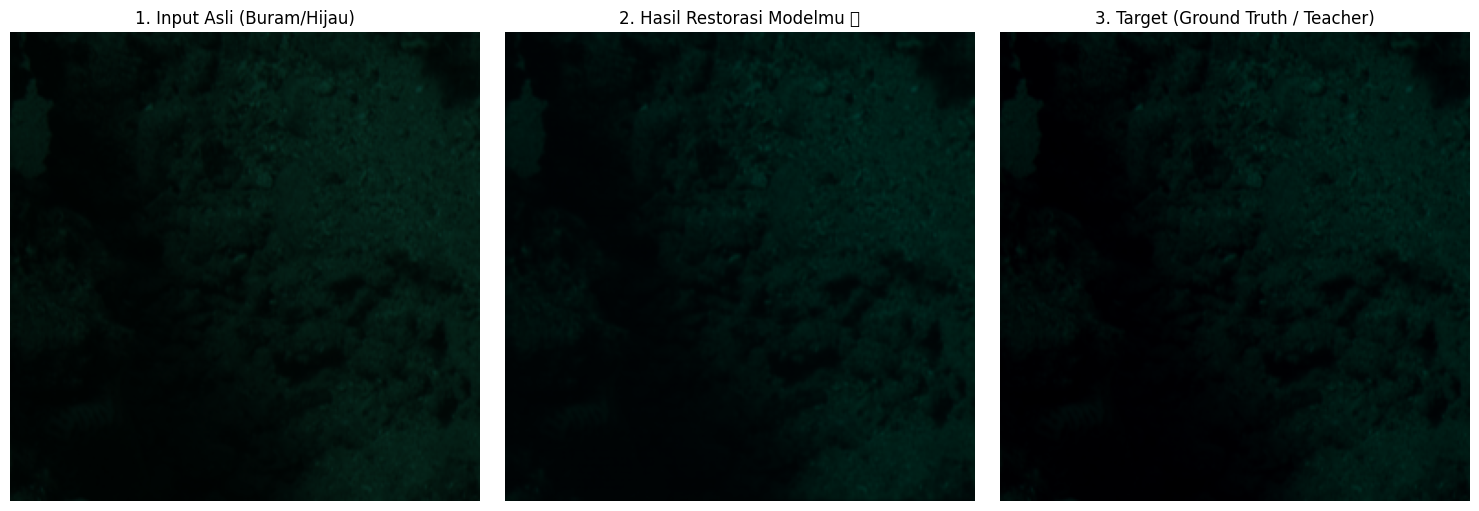

In [30]:
import matplotlib.pyplot as plt

# 1. Pasang otak yang udah pinter (Load Weights)
# Pastikan path-nya sesuai dengan tempat kamu save tadi
generator5.load_weights("best_generator_combo5.weights.h5")
print("Bobot pinter berhasil dipasang!")

# 2. Ambil 1 batch aja dari Test Set buat ngintip hasilnya
for rgb, depth, mask in test_ds.take(1):
    # Siapin input
    inp = make_4ch(rgb, depth)
    gt  = generate_pseudo_gt(rgb, depth, mask) # Targetnya
    
    # Suruh model nebak (Inference)
    pred_rgb = generator5.predict(inp, verbose=0)
    
    # 3. Tampilin gambarnya berjejer!
    plt.figure(figsize=(15, 5))
    
    # Asumsi gambarmu direntang [-1, 1] karena pakai aktivasi 'tanh'
    # Jadi kita balikin ke [0, 1] biar bisa ditampilin matplotlib
    
    plt.subplot(1, 3, 1)
    plt.title("1. Input Asli (Buram/Hijau)")
    plt.imshow((rgb[0].numpy() + 1.0) / 2.0)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("2. Hasil Restorasi Modelmu 🔥")
    plt.imshow((pred_rgb[0] + 1.0) / 2.0)
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("3. Target (Ground Truth / Teacher)")
    plt.imshow((gt[0].numpy() + 1.0) / 2.0)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    break # Berhenti setelah nampilin 1 gambar

Bobot Combo 4 & Combo 5 berhasil dipasang! Siap tanding 🔥


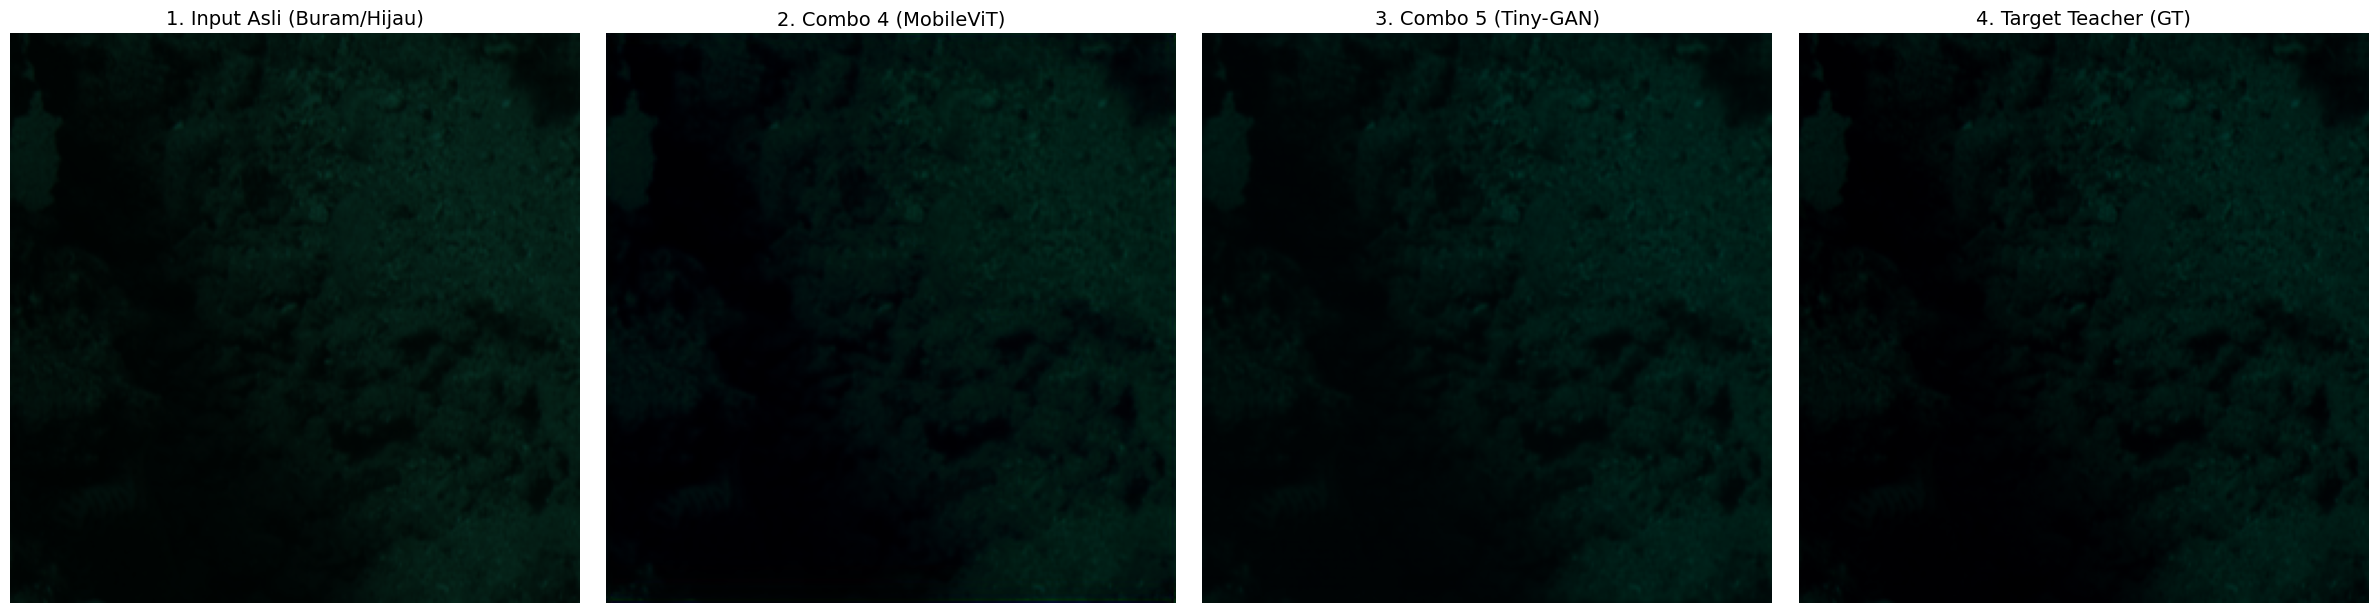

In [31]:
import matplotlib.pyplot as plt

# 1. Panggil dan pasang "otak" buat KEDUA model
# Menggunakan nama variabel dan nama file yang sesuai dengan notebook-mu
student4.load_weights("/kaggle/working/best_student_combo4.weights.h5")
generator5.load_weights("/kaggle/working/best_generator_combo5.weights.h5")
print("Bobot Combo 4 & Combo 5 berhasil dipasang! Siap tanding 🔥")

# 2. Ambil 1 batch dari Test Set
for rgb, depth, mask in test_ds.take(1):
    # Siapin input 4-channel & targetnya
    inp = make_4ch(rgb, depth)
    gt  = generate_pseudo_gt(rgb, depth, mask)
    
    # 3. Suruh kedua Student nebak barengan
    pred_c4 = student4.predict(inp, verbose=0)
    pred_c5 = generator5.predict(inp, verbose=0)
    
    # 4. Tampilin 4 gambar sejajar biar gampang bandinginnya
    plt.figure(figsize=(24, 6))
    
    # Panel 1: Input Asli
    plt.subplot(1, 4, 1)
    plt.title("1. Input Asli (Buram/Hijau)", fontsize=14)
    plt.imshow((rgb[0].numpy() + 1.0) / 2.0)
    plt.axis('off')
    
    # Panel 2: Hasil Combo 4
    plt.subplot(1, 4, 2)
    plt.title("2. Combo 4 (MobileViT)", fontsize=14)
    plt.imshow((pred_c4[0] + 1.0) / 2.0)
    plt.axis('off')
    
    # Panel 3: Hasil Combo 5
    plt.subplot(1, 4, 3)
    plt.title("3. Combo 5 (Tiny-GAN)", fontsize=14)
    plt.imshow((pred_c5[0] + 1.0) / 2.0)
    plt.axis('off')
    
    # Panel 4: Target Ground Truth
    plt.subplot(1, 4, 4)
    plt.title("4. Target Teacher (GT)", fontsize=14)
    plt.imshow((gt[0].numpy() + 1.0) / 2.0)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    break # Berhenti di 1 gambar aja